# 1. Exploratory Data Analysis

Here, we are establishing a deeper understanding of the dataset. The aim is to do a simple EDA, looking to understand our data structure, check for class imbalances, check for missing values in key columns (phase, enrollment_count, etc.). Plot distributions of numerical features and counts for categorical features.  Briefly examine the brief_summary and eligibility_criteria.


In [1]:
# load libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

In [2]:
# Load the complete dataset
dataset = load_dataset("louisbrulenaudet/clinical-trials")

# Access train split
train_data = dataset["train"]

print(f"Dataset size: {len(train_data)}")
print(f"Features: {train_data.features}")

Using the latest cached version of the dataset since louisbrulenaudet/clinical-trials couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\esthe\.cache\huggingface\datasets\louisbrulenaudet___clinical-trials\default\0.0.0\67359a8b9906e52190457a4be6bc9bce903d7e23 (last modified on Sun Oct 26 12:38:54 2025).


Dataset size: 541897
Features: {'nct_id': Value('string'), 'updated_at': Value('timestamp[us]'), 'brief_title': Value('string'), 'official_title': Value('string'), 'acronym': Value('string'), 'study_type': Value('string'), 'overall_status': Value('string'), 'study_first_submit_date': Value('timestamp[ms]'), 'start_date': Value('timestamp[ms]'), 'primary_completion_date': Value('timestamp[ms]'), 'completion_date': Value('timestamp[ms]'), 'phases': List(Value('string')), 'enrollment_count': Value('float64'), 'minimum_age': Value('float64'), 'maximum_age': Value('float64'), 'sex': Value('string'), 'healthy_volunteers': Value('bool'), 'brief_summary': Value('string'), 'detailed_description': Value('string'), 'eligibility_criteria': Value('string'), 'lead_sponsor_name': Value('string'), 'lead_sponsor_class': Value('string'), 'org_study_id_info': {'id': Value('string'), 'link': Value('string'), 'type': Value('string')}, 'why_stopped': Value('string'), 'expanded_access_info': {'hasExpandedAcc

In [3]:
# convert our dataframe into a pandas dataframe for easier analysis
train_df = train_data.to_pandas()

# Display the first few rows to confirm it worked
print("DataFrame created successfully. Here are the first 5 rows:")
train_df.head()

DataFrame created successfully. Here are the first 5 rows:


,nct_id,updated_at,brief_title,official_title,acronym,study_type,overall_status,study_first_submit_date,start_date,primary_completion_date,...,locations,collaborators,arm_groups,outcomes,overall_officials,study_references,misc_info_module,condition_browse_module,intervention_browse_module,mesh_terms
0,NCT01273766,NaT,Deferasirox in Treating Iron Overload Caused B...,Impact of Intervention With Deferasirox on the...,None,INTERVENTIONAL,COMPLETED,2011-01-07,NaT,NaT,...,"[{'city': 'Winston-Salem', 'country': 'United ...","[{'class': 'NIH', 'name': 'National Cancer Ins...",None,"{'other': None, 'primary': [{'description': No...",[{'affiliation': 'Wake Forest University Healt...,None,"{""versionHolder"": ""2025-06-18""}","{'ancestors': [{'id': 'D004194', 'term': 'Dise...","{'ancestors': [{'id': 'D007502', 'term': 'Iron...","{'conditions': [{'id': 'D002051', 'term': 'Bur..."
1,NCT00787566,NaT,"Phase 2 Study of Efficacy, Tolerability, and S...","A Randomized, Single Administration, Double-bl...",None,INTERVENTIONAL,COMPLETED,2008-11-05,NaT,NaT,...,[{'city': 'The study is managed by Kendle Inte...,None,None,"{'other': None, 'primary': [{'description': No...",None,None,"{""versionHolder"": ""2025-06-18""}","{'ancestors': [{'id': 'D012817', 'term': 'Sign...","{'ancestors': [{'id': 'D000932', 'term': 'Anti...","{'conditions': [{'id': 'D009325', 'term': 'Nau..."
2,NCT00497666,NaT,Association Between Rosiglitazone Use and Clin...,Retrospective Study Evaluating the Association...,None,OBSERVATIONAL,UNKNOWN,2007-07-06,NaT,NaT,...,"[{'city': 'Zerifin,', 'country': 'Israel', 'fa...",None,None,None,"[{'affiliation': 'Nephrology Division, Assaf H...",None,"{""versionHolder"": ""2025-06-18""}","{'ancestors': [{'id': 'D014570', 'term': 'Urol...","{'ancestors': None, 'browseBranches': [{'abbre...","{'conditions': [{'id': 'D007674', 'term': 'Kid..."
3,NCT01978366,NaT,Open Label Extension Study of HT-100 in Patien...,An Open Label Extension Study of HT-100 in Pat...,None,INTERVENTIONAL,TERMINATED,2013-10-31,NaT,2016-04-30,...,"[{'city': 'Sacramento', 'country': 'United Sta...",None,None,"{'other': None, 'primary': [{'description': No...","[{'affiliation': 'AkashiTherapeutics', 'name':...",None,"{""versionHolder"": ""2025-06-18""}","{'ancestors': [{'id': 'D020966', 'term': 'Musc...","{'ancestors': [{'id': 'D000970', 'term': 'Anti...","{'conditions': [{'id': 'D009136', 'term': 'Mus..."
4,NCT01971866,NaT,Camera Based System to Monitor Patient Movemen...,Improving Safety and Accuracy of Proton Therap...,DS02,OBSERVATIONAL,TERMINATED,2013-10-17,NaT,NaT,...,"[{'city': 'Jacksonville', 'country': 'United S...",None,None,"{'other': None, 'primary': [{'description': No...",[{'affiliation': 'University of Florida Proton...,None,"{""versionHolder"": ""2025-06-18""}",None,None,None


### Analyze the Target Variable: overall_status
Our first goal is to understand what we're trying to predict. We need to see all the possible values for overall_status and how often they appear.


Distribution of Clinical Trial Statuses:
overall_status
COMPLETED                    296549
UNKNOWN                       79051
RECRUITING                    66429
TERMINATED                    31493
NOT_YET_RECRUITING            23878
ACTIVE_NOT_RECRUITING         20916
WITHDRAWN                     15333
ENROLLING_BY_INVITATION        4655
SUSPENDED                      1674
WITHHELD                        920
NO_LONGER_AVAILABLE             490
AVAILABLE                       264
APPROVED_FOR_MARKETING          220
TEMPORARILY_NOT_AVAILABLE        25
Name: count, dtype: int64


C:\Users\esthe\AppData\Local\Temp\ipykernel_14968\1821292244.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.index, y=status_counts.values, palette="viridis")


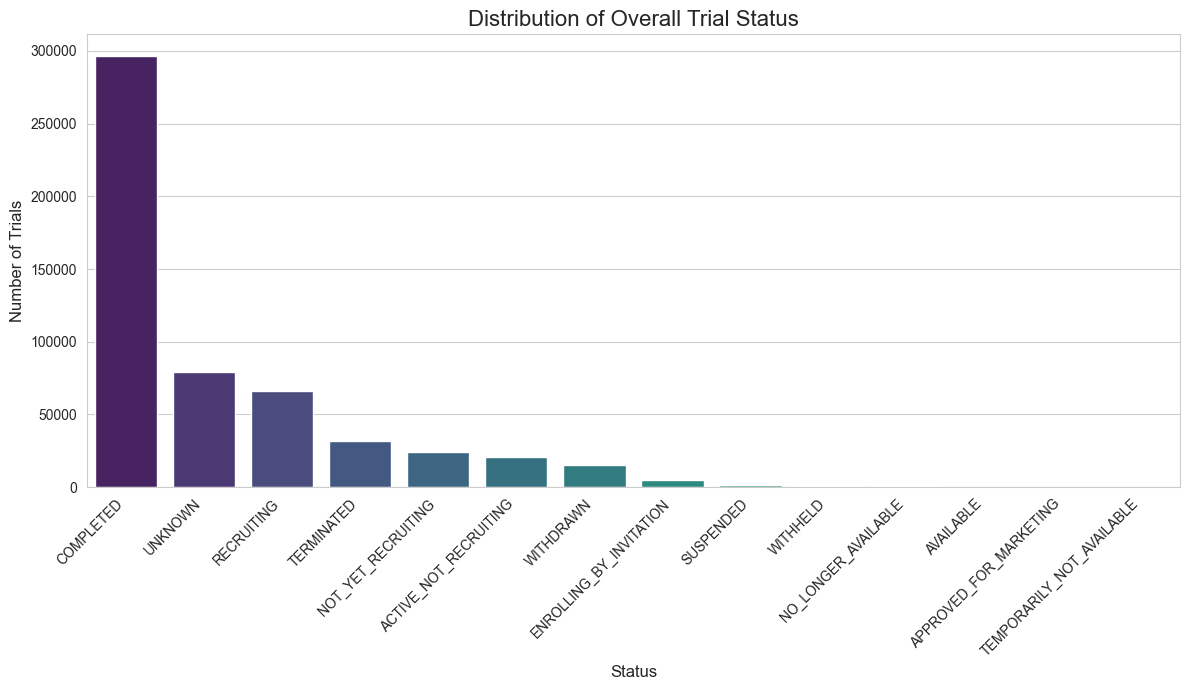

In [4]:
# Set the style for our plots
sns.set_style("whitegrid")

# 1. Get the counts of each status
status_counts = train_df['overall_status'].value_counts()
print("Distribution of Clinical Trial Statuses:")
print(status_counts)

# 2. Visualize the distribution
plt.figure(figsize=(12, 7))
sns.barplot(x=status_counts.index, y=status_counts.values, palette="viridis")
plt.title('Distribution of Overall Trial Status', fontsize=16)
plt.xlabel('Status', fontsize=12)
plt.ylabel('Number of Trials', fontsize=12)
plt.xticks(rotation=45, ha="right") # Rotate labels for better readability
plt.tight_layout() # Adjust plot to ensure everything fits without overlapping
plt.show()

### Discussion on the classes

Above, you can see all the different classes we have avalable in the "overall_status" column. They are hihgly imbalanced. So now, what I want to do is to simplify this column into a new binary target. 

For our project, we want to predict a clear outcome: Success vs. Failure. A trial that is "Recruiting" hasn't failed yet, so it's not useful for our model. So far, columns that seem like they are stopped for a reason are good targets for "failure", and the "complete" class is good as our "success". 

So, the simplification is: 

- **Success (Target = 1):** We define success strictly as trials marked "COMPLETED".

- **Failure (Target = 0):** We define failure as trials that were stopped due to negative outcomes. We include "TERMINATED" (stopped permanently), "WITHDRAWN" (stopped before enrollment), and "SUSPENDED" (halted due to problems).

We exclude other statuses like "Recruiting" or "Active, not recruiting" as their final outcome is not yet known. This filtering provides us with a clear, unambiguous dataset for training a predictive model.

Original DataFrame size: 541897
Filtered DataFrame size: 345049

Distribution of our new binary target:
target
1    296549
0     48500
Name: count, dtype: int64


C:\Users\esthe\AppData\Local\Temp\ipykernel_14968\2282118295.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=filtered_df, palette="coolwarm")


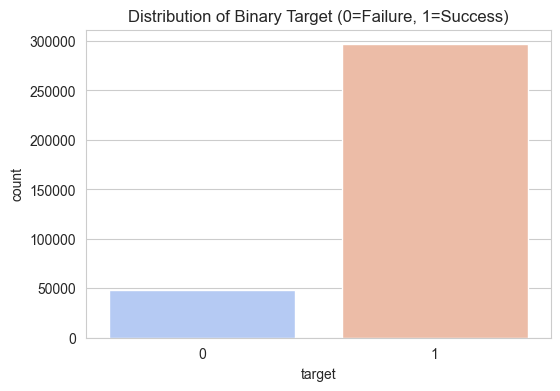

In [5]:
# Define what constitutes success and failure
success_stati = ["COMPLETED"]
failure_stati = ["TERMINATED", "WITHDRAWN", "SUSPENDED"]

# Filter the DataFrame to only include trials with these definitive outcomes
filtered_df = train_df[train_df['overall_status'].isin(success_stati + failure_stati)].copy()

# Create the binary 'target' column
filtered_df['target'] = filtered_df['overall_status'].apply(lambda x: 1 if x in success_stati else 0)

# Check the new distribution
print(f"Original DataFrame size: {len(train_df)}")
print(f"Filtered DataFrame size: {len(filtered_df)}")
print("\nDistribution of our new binary target:")
print(filtered_df['target'].value_counts())

# Visualize the new binary target
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=filtered_df, palette="coolwarm")
plt.title('Distribution of Binary Target (0=Failure, 1=Success)')
plt.show()

### Class imbalance thoughts

Even after we create our binary classes, we still have aproxx 1:6 failure to success rate. Right now, I wont be doing anything to "fix" this, however, we will need to address this during the modeling phase using techniques such as downsampling the majority class, oversampling the minority class (e.g., SMOTE), or using class weights in our model's loss function.

### Structured data and feature analysis

Now that we have a clean, well-defined target variable, we should analyze the features we'll use to predict it. We'll focus on finding a few canidates. 

Here are some of my thoughts on some of the different columns, and why they could be important predictors:

**"phases"** 
- This is arguably the strongest predictor in my opinion. Early-phase trials (Phase 1, Phase 2) are designed to be exploratory and have a naturally high failure rate as they test for safety and initial efficacy. Later-phase trials (Phase 3) are much larger and more expensive, and they only happen after a study/drug/trial has shown promise, so they are expected to have a different success rate.

**"study_type"**
- The design of the study is fundamental. An "Interventional" study (where a new drug is tested) is inherently riskier and more prone to failure than an "Observational" study (where researchers just observe outcomes without intervention).

**"enrollment_count"**
- This represents the size and ambition of a trial. A very low enrollment target might indicate a small, exploratory study. A very high target is typical of a Phase 3 trial. Difficulty in recruiting the target number of patients is also a major reason for trial termination, so this number is a key indicator of operational complexity.

**"'lead_sponsor_class'"**
- The organization funding the trial is critical. A large pharmaceutical company ("Industry") has different resources, motivations, and processes than an academic university ("Academia") or a government body ("NIH"). We could also then hypothesize that industry-sponsored trials might have different success patterns than academic ones, and we will likely group these into classes.

**"sex"** 
- This defines the target population. Trials targeting "All" participants may be easier to recruit for than those targeting only "Male" or "Female." This can also be an indicator for specific types of diseases (e.g., prostate vs. ovarian cancer) which may have different research challenges.

**"minimum_age" / "maximum_age"**
- These features also define the target population. Trials involving vulnerable populations, like children (pediatric) or the elderly (geriatric), can face more complex ethical and medical challenges, potentially leading to higher rates of suspension or termination. These fields tell us about the complexity of the patient cohort. Note: These are often text fields (e.g., "18 Years") and will need cleaning.

In [6]:
# checking for missing values
# Use the DataFrame that was filtered and has the binary target
df_for_eda = filtered_df.copy()

# Select a subset of promising structured features to analyze
# Using corrected names from the Hugging Face schema
structured_features = [
    'phases', 'study_type', 'enrollment_count', 
    'lead_sponsor_class', 'sex', 'minimum_age', 'maximum_age'
]

# Check for missing values in these key columns
missing_values = df_for_eda[structured_features].isnull().sum()

print("Missing values in key structured features:")
# We'll print the percentage of missing values for better context
missing_percentage = (missing_values / len(df_for_eda)) * 100
print(missing_percentage[missing_percentage > 0].sort_values(ascending=False))

Missing values in key structured features:
maximum_age         46.706700
phases              20.687786
minimum_age          6.537622
enrollment_count     1.242142
sex                  0.088973
dtype: float64


### What to do with the missing data? 

The output we got above shows the different % of missing data in our chosen columns. Most models dont handle missing data, so we need to clean our data. 

Depending on how much data is missing, we have some different options on what to do. 

| Missing Percentage | Severity  | Our Strategy                                                                                                                                       |
|--------------------|-----------|---------------------------------------------------------------------------------------------------------------------------------------------------|
| < 2-3%             | Low       | The problem is tiny. The easiest and cleanest solution is to simply **drop the few rows** that have these missing values. We won't lose much data. |
| 3% - 50%           | Moderate  | Dropping is too risky; we'd throw away too much valuable data. We need to intelligently **fill in the gaps (impute)**.                           |
| > 50%              | High      | The column is mostly empty and potentially useless. We might consider **dropping the entire column**, as it doesn't contain much information.    |


Based on our output, here is our action plan:

1. sex (0.08%) and enrollment_count (1.24%):
    - Problem: Tiny amount missing.

    - Decision: We will drop the rows where these values are missing. It's the simplest and best solution.

2. phases (20.7%) and minimum_age (6.5%):
    - Problem: Moderate amount missing.

    - Decision: We must impute (fill in) these values.

        - For phases, we can treat "missing" as its own category, like "Unknown". This is often a good strategy for categorical data.

        - For minimum_age, we could fill the missing values with the median age of the dataset.

3. maximum_age (46.7%):

    - Problem: High amount missing. This is a tricky one.

    - Decision: Dropping the column would be a loss of potentially useful information. A better approach for now is to also impute it, but we need to be careful. We could fill it with the median, or perhaps a very high number like "100" to signify no upper age limit. We also need to clean the age columns, as they are likely text (e.g., "18 Years").

### distributions of categorical features


Analyzing the 'phases' column...


C:\Users\esthe\AppData\Local\Temp\ipykernel_14968\3602420806.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=phase_counts.index, y=phase_counts.values, palette='plasma')


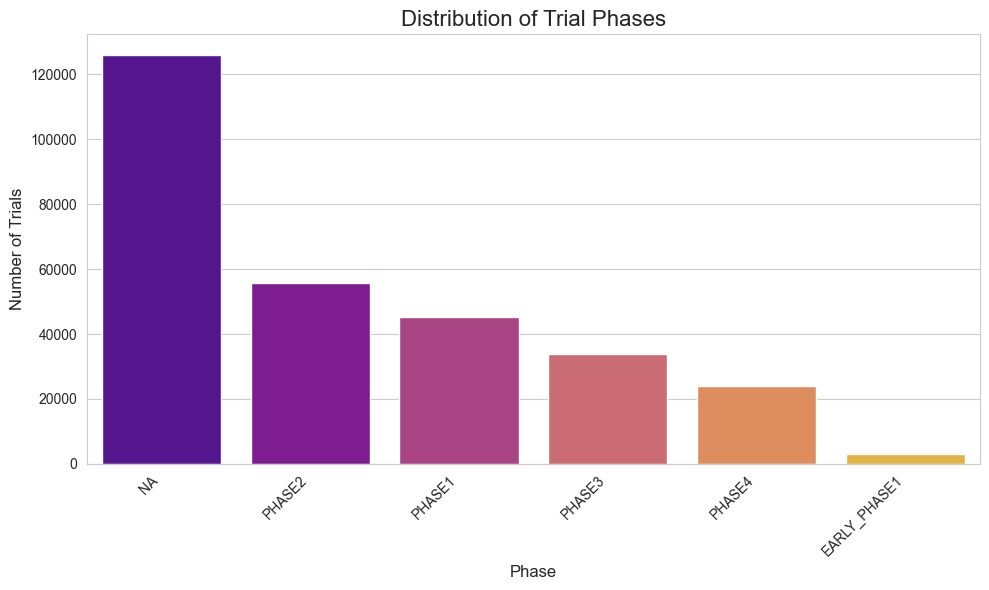


Analyzing other categorical features...


C:\Users\esthe\AppData\Local\Temp\ipykernel_14968\3602420806.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df_for_eda, ax=axes[i], palette='viridis', order=df_for_eda[feature].value_counts().index)
C:\Users\esthe\AppData\Local\Temp\ipykernel_14968\3602420806.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df_for_eda, ax=axes[i], palette='viridis', order=df_for_eda[feature].value_counts().index)
C:\Users\esthe\AppData\Local\Temp\ipykernel_14968\3602420806.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

 

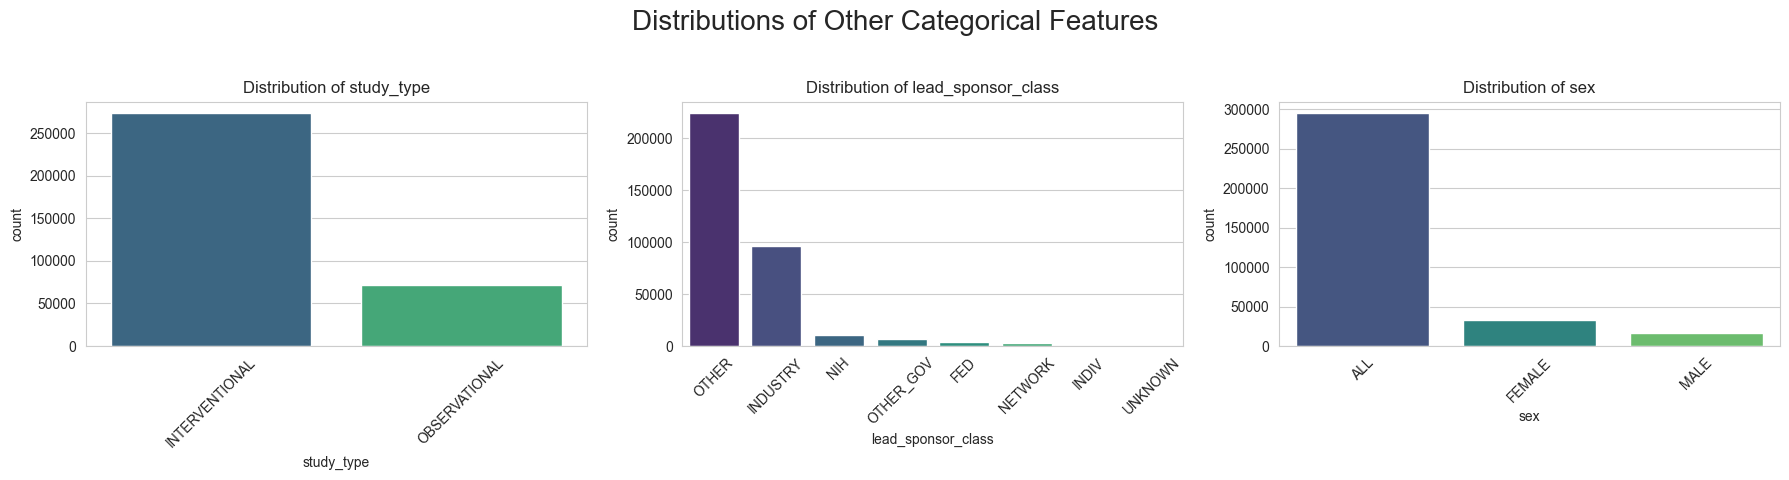

In [ ]:
# --- 1. Correctly analyze and plot the 'phases' column ---
print("Analyzing the 'phases' column...")

# Explode the series to get one row per phase, and then get the value counts.
# This is fast and handles the array/list structure correctly.
phase_counts = df_for_eda['phases'].explode().value_counts()

# Now, create a bar plot of the pre-calculated counts
plt.figure(figsize=(10, 6))
sns.barplot(x=phase_counts.index, y=phase_counts.values, palette='plasma')
plt.title('Distribution of Trial Phases', fontsize=16)
plt.xlabel('Phase', fontsize=12)
plt.ylabel('Number of Trials', fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- 2. Plot the other categorical features ---

simple_categorical_features = ['study_type', 'lead_sponsor_class', 'sex']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distributions of Other Categorical Features', fontsize=20)
axes = axes.flatten()

for i, feature in enumerate(simple_categorical_features):
    # This code works because the data it's plotting doesn't have the duplicate index issue
    sns.countplot(x=feature, data=df_for_eda, ax=axes[i], palette='viridis', order=df_for_eda[feature].value_counts().index)
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Plot analysis: 

**Looking at the "phases" plot**, we not see a huge category labeled "NA". Here we have to remember that our erlier aproxx. 20% missing data we saw, was cells with no data(NaN), meanwhile the NA is filled in by the creators of the data, intentionally. This can be for different reasons, for example if the trial does not have phases. For example, an "Observational" study doesn't have a clinical "phase," so its phase is correctly "Not Applicable.". This means that we can treat "NA" as a distinct category that our model can learn from. Our hypothesis might be that trials with phase "NA" (likely observational) have a very different success rate than interventional Phase 3 trials. 

**Looking at the "lead_sponsor_class" plot**, we can see a long tail distribution, where most of the data is labelled as "OTHER". This is not very infromative. For now, I will treat this as its own single category. I will just aknowledge this a s a data limitation for now, in P2. It can still be a useful feature if trials sponsored by "INDUSTRY" or "NIH" have a different success rate than "OTHER". 

However, when we have moved into P3, we could, if we wanted to improve the model, perform a sub-analysis on the lead_sponsor_name column for all trials where lead_sponsor_class is "OTHER". We could find the top 5 most common sponsors within "OTHER" and create new categories for them, leaving the rest in a smaller "OTHER" bucket.

**Looking at the "study_type" plot**, we see that most of the trials are "INTERVENTIONAL". This is a reflection of reality. This is still a very powerful feature. Our model will almost certainly learn that interventional studies have a different failure rate than observational ones.

**Looking at the "sex" plot**, we see that an overwhelming majority of studyies accept both genders. The model can learn from this. The MALE vs FEMALE ratio is also interesting, and the model might find patterns there for specific conditions.

### distributions of numerical features

To start out, ill chekc if my numerical columns are truly numerical. I am mainly doing this because I want to make sure that the two age columns are actually numerical, because datasets will often include pseudo numerical values, where instead of having 25 as a number, we will have "25" or "25 years" as a string. But we just need to chek them to make sure beofre we move on. 


In [8]:
# List of our potential numerical features
numerical_features_to_check = ['enrollment_count', 'minimum_age', 'maximum_age']

# Check the data type of each column
print("Data types of potential numerical features:")
print(df_for_eda[numerical_features_to_check].dtypes)

Data types of potential numerical features:
enrollment_count    float64
minimum_age         float64
maximum_age         float64
dtype: object


Here, I will look at summary statistics. This is because I want to get some ideas on the distributions before I plot them so that I can chose the best visalization. 

The pandas.describe() method is my primary tool here. It gives me the count, mean, standard deviation, min, max, and quartile values. The key to detecting skew is to compare the mean and the median (the 50% mark). The Rule of Thumb:
- If the mean is much larger than the median, the data is right-skewed. This means there is a "tail" of very high values pulling the average up.
- If the mean is much smaller than the median, the data is left-skewed.
- If the mean and median are very close, the data is likely symmetrical (like a bell curve).

In [9]:
# Our confirmed list of numerical features
numerical_features = ['enrollment_count', 'minimum_age', 'maximum_age']

# Generate summary statistics for all numerical columns at once
summary_stats = df_for_eda[numerical_features].describe()

print("Summary statistics for all numerical features:")
summary_stats

Summary statistics for all numerical features:


,enrollment_count,minimum_age,maximum_age
count,3.407630e+05,322491.000000,183888.000000
mean,4.124893e+03,20.080337,58.631335
std,3.981039e+05,11.267044,31.160500
min,0.000000e+00,0.000000,1.000000
25%,2.400000e+01,18.000000,45.000000
50%,6.000000e+01,18.000000,65.000000
75%,1.590000e+02,18.000000,75.000000
max,1.888141e+08,730.000000,6569.000000


For the "enrollment_count" column, we see a massive, extreme right skew. The mean is almost 70 times larger than the median. This tells us that while the "typical" trial has around 60 participants, there are a few gigantic "mega-trials" with millions of participants that are dragging the average way up.

For "maximum_age", the mean (58.6) is a bit smaller than the median (65). This suggests a slight left skew, meaning there's a tail of studies with unusually low maximum ages. However what us strange about it is that we have a min of 1, in a maximum column, which is a bit strange. It might have something to do with infanry studies, but thats something we need further analysis for. The max value of this column is also 6569, which I hope is a data entry error. 

For "minimum_age", the mean (20.08) is slightly larger than the median (18). This is a slight right skew, but much less dramatic than the enrollment count. This column has a min of 0, which is plausable. It could represent studies on newborns where age is measured in days/weeks, but recorded as 0 years. However, the max value of this column is 730. It's impossible for a study to have a minimum age of 730.

So, what we have found out is:
1. All three numerical features are heavily skewed.
2. The age columns contain clear data entry errors/outliers.

This provides us with a data-driven justification for our next step: visualization. We now know that simply plotting a standard histogram will be unreadable. We must use a log scale to handle the skew we've just proven exists with these statistics.

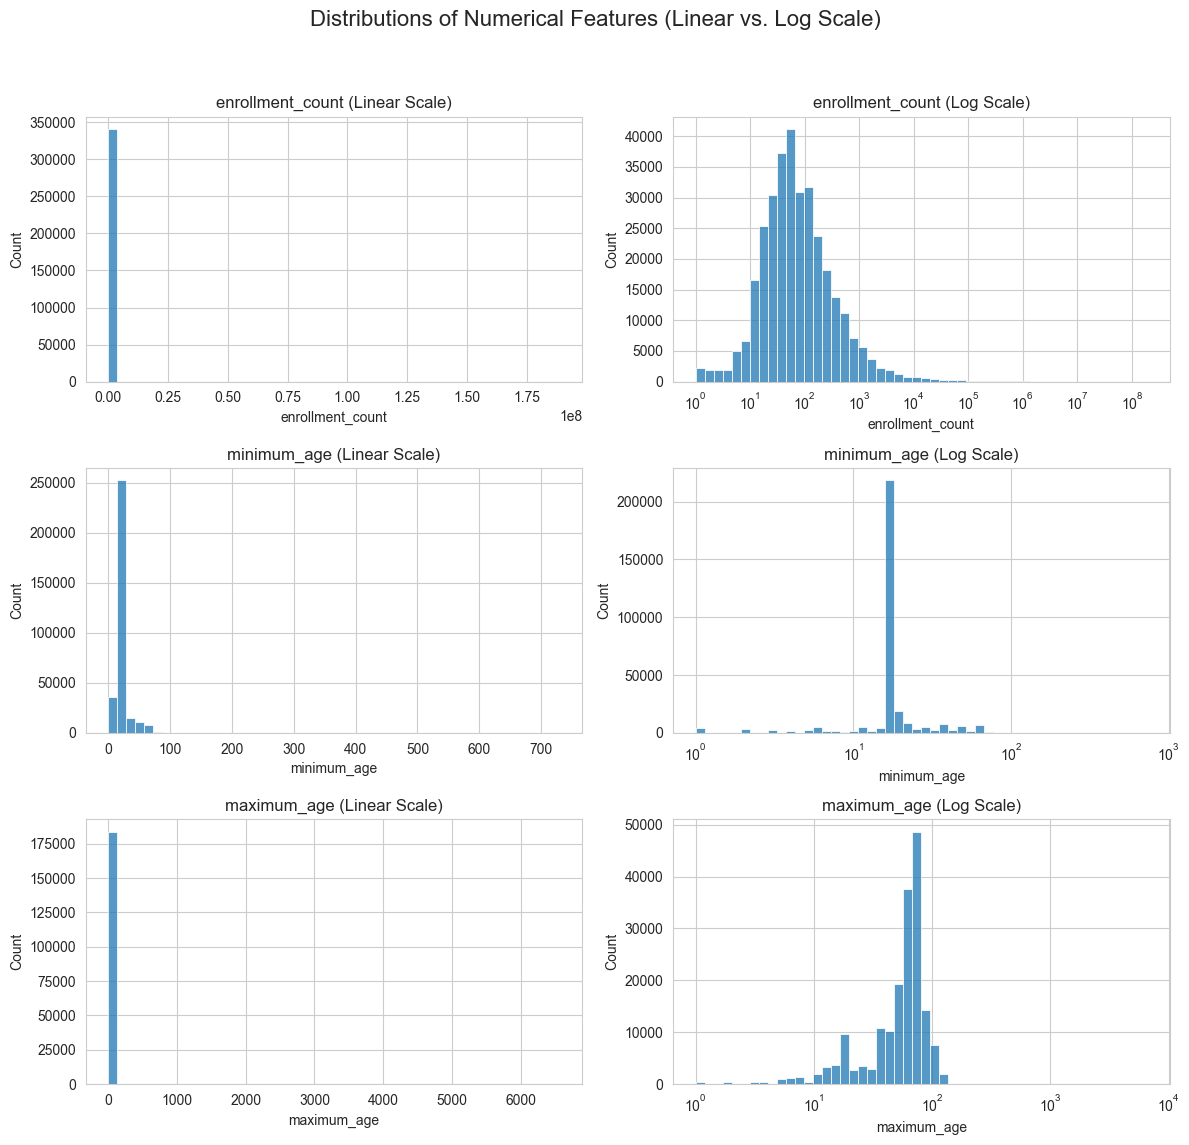

In [10]:
# Our final list of numerical features
numerical_features = ['enrollment_count', 'minimum_age', 'maximum_age'] # Assuming you kept these new names

# Create plots for each numerical feature
fig, axes = plt.subplots(len(numerical_features), 2, figsize=(12, 12))
fig.suptitle('Distributions of Numerical Features (Linear vs. Log Scale)', fontsize=16)

for i, feature in enumerate(numerical_features):
    # Plot on a linear scale
    sns.histplot(df_for_eda[feature], bins=50, kde=False, ax=axes[i, 0])
    axes[i, 0].set_title(f'{feature} (Linear Scale)')
    
    # Plot on a log scale
    sns.histplot(df_for_eda[feature], bins=50, kde=False, ax=axes[i, 1], log_scale=True)
    axes[i, 1].set_title(f'{feature} (Log Scale)')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Analysis of the histograms

1. `enrollment_count`

- **Linear Scale (Left):** This plot is a perfect visual of the "extreme right skew" we saw in the stats. Almost all the data (300,000+ trials) is crushed into the very first bin on the left, and we can't see any detail. This plot is practically unreadable.

- **Log Scale (Right):** This plot is more informative. The log scale has revealed the true shape of the distribution. It's no longer a spike; it looks much more like a "bell curve" (a classic log-normal distribution). We can now clearly see that the most common trial size is centered between `10^1` and `10^2`, which is **10 to 100 participants**. This perfectly matches the median of 60 we saw earlier.



2. `minimum_age`

- **Linear Scale (Left):** This plot is actually quite informative, more so than the log version. It clearly shows a **massive, dominant spike at a single value** (which we know from our stats is 18). There's another smaller spike at 0, and very little else.

- **Log Scale (Right):** This plot is **very hard to read**. The log scale is trying to stretch an axis where most of the data is concentrated in an extremely narrow band. This creates the giant, thin spike at 18 (which is just after `10^1`). The log scale is the **wrong visualization tool** for this specific feature because the feature doesn't span many orders of magnitude.

- **Conclusion:** `minimum_age` doesn't behave like a true continuous variable. It acts more like a **categorical feature** where the overwhelming majority of trials have a `minimum_age` of **18**. 


3. `maximum_age`

- **Linear Scale (Left):** Like the first plot, this is a visual showing a typical "extreme right skew". Almost all the data is crushed into the very first bin on the left, and we can't see any detail.

- **Log Scale (Right):** This plot is more helpful than the linear one. It shows the distribution is centered around `10^1` to `10^2` (10 to 100 years). We know the median is 65, which fits perfectly in the middle of that big central peak. We can see the shape of the main cluster much more clearly than on the linear scale.

- **Conclusion:** The `maximum_age` is also right-skewed, and the log transform helps to visualize its central tendency. The typical maximum age for a trial is around **65**.


**Over all conclusion:**
1. `enrollment_count` is a classic log-normal feature.  

2. `minimum_age` is a "degenerate" numerical feature that acts more like a categorical one, with a huge spike at 18.  

3. `maximum_age` is a more standard, continuous skewed feature where the typical value is around 65.  


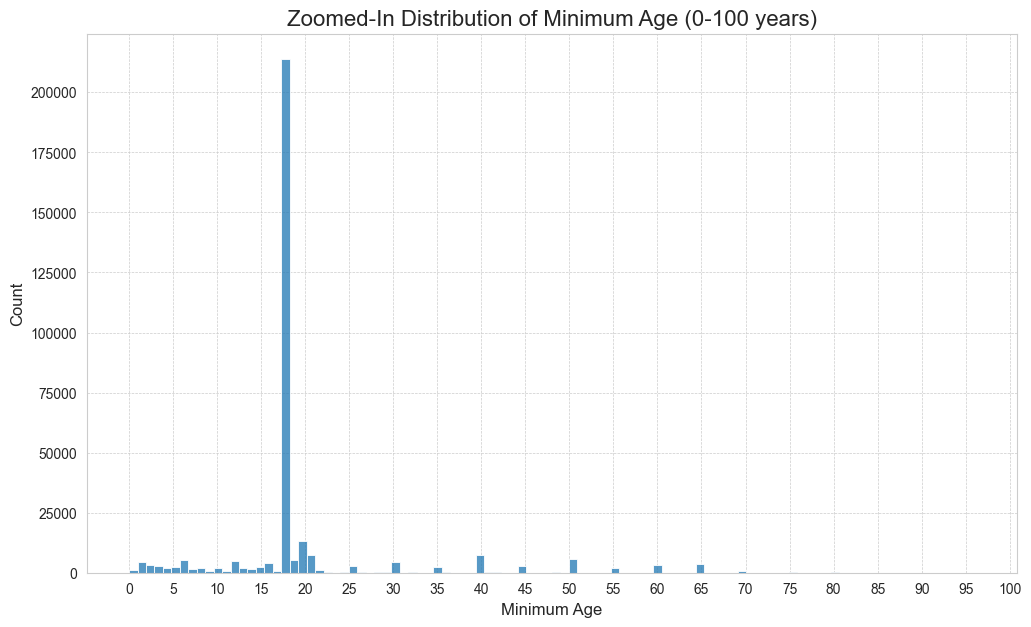

In [11]:
# Create a filtered view of the data for plotting, excluding extreme outliers
zoomed_df = df_for_eda[df_for_eda['minimum_age'] <= 100]

# Now, create a new histogram with this filtered data
plt.figure(figsize=(12, 7))
sns.histplot(data=zoomed_df, x='minimum_age', bins=100) # Using more bins for more detail
plt.title('Zoomed-In Distribution of Minimum Age (0-100 years)', fontsize=16)
plt.xlabel('Minimum Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(ticks=range(0, 101, 5)) # Add ticks every 5 years for clarity
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

looking at a zoomed in view of the minimum age distribution, we can see that we have many different ages listed, however, it is dominated by thwe 18 year old age group. Which makes sense. We have a somewhat considtent distribution for individuals under 18, but as we increse in age, we start seeing bigger gaps in our histogram. We see definate bins at adult ages such as 40, 45, 50 ect, which is probably due to research stating that the difference ebtween lets say 40 and 42 is meaningless, however the difference between 12 and 15 or 15 and 17 is often more interesting/ significant. 

However, this is very important for our model later on., We cant really treat this column as a simple number, because if we do, our model might learn weird or incorrect relationships. For example, it might learn that a minimum age of 60 is 3.33 times more predictive than an age of 18, which would be nonsense. The relationship here isnt linear. 

For p2, we can argue that since we are focusing on proof-of-concept, we can keep this column numerical. But when we move to p3, we should look into how to not use the raw numbers here, potentially building a new column called "age_category" or something similar. It could include categorical age pools like "pedritric" (under 18 year olds), "young_adult", "mid_life" and "senior". However this requers some assumtions and/or data supporting which ages should be in which category. 

## 2. Data Preprocessing and Pipeline

Based on the findings from our Exploratory Data Analysis, we need to perform several preprocessing steps to prepare the data for our baseline machine learning model. Our goal is to create a clean, purely numerical feature matrix `X` and a target vector `y`.

We will encapsulate this entire process into a single, reusable function. Here is the plan for our data handling pipeline:

**Pipeline Steps:**

1.  **Select Final Features:** We will start with the subset of structured features we analyzed: `phases`, `study_type`, `enrollment_count`, `lead_sponsor_class`, `sex`, `minimum_age`, and `maximum_age`.

2.  **Create Binary Target:** We will use the binary `target` column we created earlier (1 for Success, 0 for Failure).

3.  **Handle Missing Values:** Based on our EDA, we will apply the following strategies:
    *   **Drop Rows:** For `sex` and `enrollment_count`, where less than 2% of data is missing, we will drop the corresponding rows. This is the cleanest approach for small amounts of missing data.
    *   **Impute Categorical:** For `phases`, we will fill missing (`NaN`) values with the string `"Unknown"`. This treats "missingness" as its own category.
    *   **Impute Numerical:** For `minimum_age` and `maximum_age`, we will fill missing (`NaN`) values with the **median** of each respective column. The median is a robust choice given the skewness and outliers we observed.

4.  **Encode Categorical Features:** Machine learning models require numerical input. We will convert our categorical columns (`phases`, `study_type`, `lead_sponsor_class`, `sex`) into a numerical format using **One-Hot Encoding**. This creates a new binary column for each category and avoids implying an incorrect ordinal relationship.

5.  **Scale Numerical Features:** The numerical features (`enrollment_count`, `minimum_age`, `maximum_age`) have vastly different scales. To prevent features with large values from dominating the model, we will scale them using a **StandardScaler**, which will give each feature a mean of 0 and a standard deviation of 1.

6.  **Final Output:** The pipeline will return a final, processed DataFrame ready for modeling.

In [14]:
# Import our function
from utils import fit_and_preprocess_train
import numpy as np 

# Load the training data
train_df = dataset["train"].to_pandas()

# Unpack the two returned items into two separate variables
processed_train_df, transformation_rules = fit_and_preprocess_train(train_df)

# inspect each one individually
print("\nDataFrame after preprocessing:")
display(processed_train_df.head())

print("\nLearned Transformation Rules:")
print(transformation_rules)

Dropped 4565 rows with missing 'sex' or 'enrollment_count'.
Training data preprocessed successfully according to the specific plan.

DataFrame after preprocessing:


,enrollment_count,minimum_age,maximum_age,phases_EARLY_PHASE1,phases_NA,phases_PHASE1,phases_PHASE2,phases_PHASE3,phases_PHASE4,phases_Unknown,...,lead_sponsor_class_INDUSTRY,lead_sponsor_class_NETWORK,lead_sponsor_class_NIH,lead_sponsor_class_OTHER,lead_sponsor_class_OTHER_GOV,lead_sponsor_class_UNKNOWN,sex_ALL,sex_FEMALE,sex_MALE,target
0,-0.010324,-0.179089,0.150986,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1
1,-0.010193,-0.179089,0.150986,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
3,-0.010321,-1.277708,-1.806807,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
4,-0.010361,-0.179089,0.150986,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0
5,-0.010211,-0.179089,0.586051,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1



Learned Transformation Rules:
{'medians': {'minimum_age': 18.0, 'maximum_age': 65.0}, 'encoder': OneHotEncoder(handle_unknown='ignore', sparse_output=False), 'scaler': StandardScaler()}
